# Bosonic GRAPE state preparation

In this notebook, we implement a standard application of GRAPE, namely the preparation of an arbitrary state of a bosonic mode, such as one of resonant modes of a microwave cavity. Parameters are taken from Eickbusch et al, https://arxiv.org/abs/2111.06414 Table S1 (without considering the anharmonicity for simplicity). Our starting point is the well-known Jaynes-Cummings Hamiltonian in the dispersive regime, which describes an interaction of a qubit with a single bosonic mode when the characteristic qubit frequency $\omega_{q}$ is far detuned from the one of the resonator $\omega_{r}$ (see for instance Blais et al, https://arxiv.org/pdf/2005.12667 for more details)

$$
H_{\mathrm{disp}} = \omega_{r} a^{\dagger} a + \frac{\omega_{q}}{2} \sigma_z + \chi \sigma_z a^{\dagger} a,
$$

where we set $\hbar = 1$ and $\chi$ is the dispersive shift, which represents a qubit-state-dependent shift of the frequency of the resonator. Note that we set conventionally $\sigma_z = | e \rangle \langle e | - |g \rangle \langle g |$, with $|e \rangle, |g \rangle$ the excited and ground state of the qubit, respectively. We additionally introduce a drive Hamiltonian on both the qubit and the resonator mode

$$
H_{d, r}(t) = \varepsilon_{d, r}(t) \cos(\omega_{d, r} t + \phi_{d, r}) (a + a^{\dagger}), \quad H_{d, q}(t) = \varepsilon_{d, q}(t) \cos(\omega_{d, q} t + \phi_{d, q}) (\sigma_- + \sigma_+).
$$

The total Hamiltonian is

$$
H(t) = H_{\mathrm{disp}} + H_{d, r}(t) + H_{d, q}(t).
$$

We assume that the qubit and the resonator are both driven resonantly, i.e., $\omega_{d, q} = \omega_q$ and $\omega_{d,r}=\omega_r$, and work in the interaction picture (rotating frame) with reference Hamiltonian

$$
H_{\mathrm{ref}} = \omega_{r} a^{\dagger} a + \frac{\omega_{q}}{2} \sigma_z,
$$

so that the Hamiltonian in the interaction picture is

$$
H_{I}(t) = e^{i H_{\mathrm{ref}} t} (H(t) - H_{\mathrm{ref}}) e^{-i H_{\mathrm{ref}} t} = \chi \sigma_z a^{\dagger} a + \varepsilon_{d, r}(t) \cos(\omega_{r} t + \phi_{d, r}) (a e^{-i \omega_r t} + a^{\dagger} e^{i \omega_r t}) + \varepsilon_{d, q}(t) \cos(\omega_{q} t + \phi_{d, q}) (\sigma_- e^{-i \omega_q t} + \sigma_+ e^{i \omega_q t}),
$$

Finally, we perform a rotating wave approximation (RWA) and neglect terms that rotate at $e^{ \pm i \omega_q t}$ and $e^{\pm i \omega_r t}$ and approximate the Hamiltonian as

$$
H_{I}(t) \overset{\mathrm{RWA}}{\approx} \chi \sigma_z a^{\dagger} a + \frac{\varepsilon_{d, r}(t)}{2} \left(a e^{i \phi_{d, r}} + a^{\dagger} e^{-i \phi_{d,r}} \right) + \frac{\varepsilon_{d, q}(t)}{2} \left(\sigma_- e^{i \phi_{d, q}} + \sigma_+ e^{-i \phi_{d,q}} \right) 
$$



In [1]:
import numpy as np
import jax.numpy as jnp 
import matplotlib.pyplot as plt

from cthree.quantity import Quantity
from cthree.model.resonator import Resonator
from cthree.model.qubit import Qubit
from cthree.model.coupling import Coupling
from cthree.signal.envelopes import GaussEnvelope
from cthree.signal.pwc_generator import PWCGenerator
from cthree.model.closed_system import ClosedSystem
from cthree.model.rotating_frame_drive import RotatingFrameDrive
from cthree.model.composite_hamiltonian import CompositeHamiltonian
from cthree.measurement.state_transfer_fidelity import StateTransferFidelityGRAPE
from cthree.propagation.scipy_expm_grape import ScipyExpmGRAPE

In [2]:
delta_sampling = 33e-9 # See Eickbusch et al https://arxiv.org/abs/2111.06414 S9 A
n_pwc = 40
t_final = n_pwc*delta_sampling # for now just set up for trying
tlist = np.linspace(0, t_final, n_pwc + 1) 
eps_res = 0.005
eps_qubit = 0.005
tone_res = GaussEnvelope(amplitude=Quantity(2*np.pi*eps_res*1e9, -5*2*np.pi*eps_res*1e9, 5*2*np.pi*eps_res*1e9), t_final=Quantity(t_final, 1/2*t_final, 2*t_final))
tone_qubit = GaussEnvelope(amplitude=Quantity(2*np.pi*eps_qubit*1e9, -5*2*np.pi*eps_qubit*1e9, 5*2*np.pi*eps_qubit*1e9), t_final=Quantity(t_final, 1/2*t_final, 2*t_final))
gen_res = PWCGenerator(envelopes=[tone_res], tlist=tlist)
gen_res.multiply_flat_top = True
gen_qubit = PWCGenerator(envelopes=[tone_qubit], tlist=tlist)
gen_qubit.multiply_flat_top = True

We plot the resonator tone and compare it to its smooth version. Similarly one can plot the qubit tone.

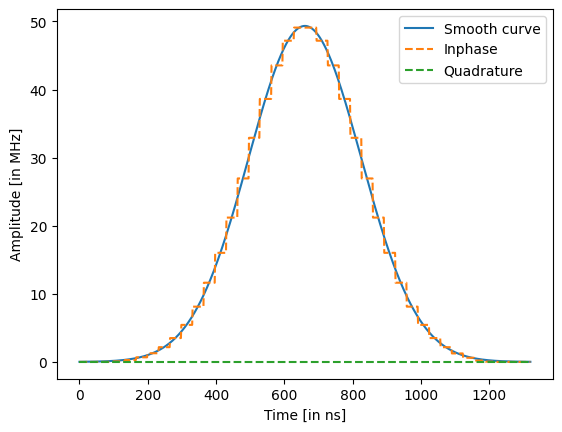

In [3]:
ts = np.linspace(0, t_final, 1001)

plt.plot(ts/1e-9, tone_res.compute_output(ts)/1e6/2*np.pi, label="Smooth curve")
plt.plot(ts/1e-9, np.real(gen_res.generate_signal(ts))/1e6/2*np.pi, ls="--", label="Inphase")
plt.plot(
    ts / 1e-9,
    np.imag(gen_res.generate_signal(ts)) / 1e6,
    ls="--",
    label="Quadrature",
)

plt.xlabel("Time [in ns]")
plt.ylabel("Amplitude [in MHz]")
plt.legend()
plt.show()

In [4]:


n_fock = 5

omega_range_factor = 1e-3 # just for initialization of the Quantity object
omega_res = 2*np.pi*5.26e9
omega_qubit = 2*np.pi*6.65e9

omega_drive_res = omega_res 
omega_drive_qubit = omega_qubit

detuning_drive_res = omega_res - omega_drive_res
detuning_drive_qubit = omega_qubit - omega_drive_qubit

drive_res = RotatingFrameDrive(gen_res)
drive_qubit = RotatingFrameDrive(gen_qubit)

resonator = Resonator(
    frequency=Quantity(value=detuning_drive_res, min_value=-omega_range_factor*omega_res, max_value=omega_range_factor*omega_res), 
    dimension=n_fock,
    drives=[drive_res])
qubit = Qubit(
    frequency=Quantity(value=detuning_drive_qubit, min_value=-omega_range_factor*omega_qubit, max_value=omega_range_factor*omega_qubit),
    drives=[drive_qubit]
    )


chi = 2*np.pi*32.81e3 

coupling = Coupling(
    [resonator, qubit],
    is_longitudinal=True,
    coefficient=Quantity(
        value=chi,
        min_value=chi/2,
        max_value=2*chi
    ),
)

hamiltonian = CompositeHamiltonian([resonator, qubit], [coupling])
model = ClosedSystem(hamiltonian=hamiltonian)

In [5]:
prop = ScipyExpmGRAPE(model, res=1e9)

init = np.array([[1.0], [0.0], [0]])  # |0>
target = np.array([[0.0], [1.0], [0]])  # |1>

prop.set_initial_state(init)
prop.target_state = target

prop.use_schirmer_derivative = True

zeroone = StateTransferFidelityGRAPE(
    propagation=prop,
    initial_state=init,
    target_state=target,
    times=tlist,
)

In [6]:
def plotStates():
    """Plot the states."""
    ts = np.linspace(0, t_final, 1001)
    states = prop.propagate(ts)
    sig = gen.generate_signal(ts)

    fig, ax = plt.subplots(2, figsize=(4, 4), sharex=True)
    ax[0].plot(ts / 1e-9, np.real(sig), label="I")
    ax[0].plot(ts / 1e-9, np.imag(sig), label="Q")
    ax[0].legend(loc=1)
    ax[0].set_ylabel("Field [MHz]")
    ax[1].plot(ts / 1e-9, np.abs(states)[:, :, 0] ** 2)
    ax[1].set_ylabel("Population")
    ax[-1].set_xlabel("Time [ns]")
    return fig, ax


plotStates()

TypeError: dot_general requires contracting dimensions to have the same shape, got (10,) and (3,).